In [37]:
import os

import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using:", device)


Using: mps


<div style="border-left: 4px solid #2563eb; background: #eff6ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — CIFAR-10 input</strong><br>Each image has three color channels and is 32 &times; 32 pixels. <code>ToTensor()</code> produces a tensor shaped <code>[3, 32, 32]</code>, and normalization changes values from <code>[0, 1]</code> to approximately <code>[-1, 1]</code>.</div>

In [38]:
# Use a faster mirror if CIFAR-10 needs to be downloaded again.
datasets.CIFAR10.url = "https://huggingface.co/datasets/VerisimilitudeX/cifar10/resolve/main/cifar-10-python.tar.gz?download=true"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5),
    ),
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [39]:
image, label = train_dataset[0]

print(image.shape)  # Should be [3, 32, 32] for CIFAR-10

print(label)  # Should be an integer between 0 and 9


torch.Size([3, 32, 32])
6


<div style="border-left: 4px solid #2563eb; background: #eff6ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Data loaders</strong><br>A data loader delivers small batches to the network. With <code>batch_size = 64</code>, each image batch has shape <code>[64, 3, 32, 32]</code>. Training data is shuffled each epoch; test data stays in a consistent order.</div>

In [40]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


<div style="border-left: 4px solid #d97706; background: #fffbeb; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Displaying a tensor as an image</strong><br><code>image / 2 + 0.5</code> reverses the earlier normalization. PyTorch stores images as channels-first <code>[C, H, W]</code>, while Matplotlib expects <code>[H, W, C]</code>, so <code>permute(1, 2, 0)</code> rearranges the axes.</div>

torch.Size([64, 3, 32, 32])
torch.Size([64])
torch.Size([3, 32, 32])
torch.Size([32, 32, 3])


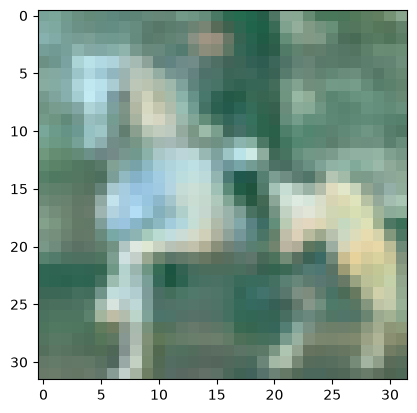

In [41]:
images, labels = next(iter(train_loader))

print(images.shape)   # [64, 3, 32, 32]
print(labels.shape)   # [64]

image = images[0]

print(image.shape)    # [3, 32, 32]

image = image / 2 + 0.5

image = image.permute(1, 2, 0)

print(image.shape)    # [32, 32, 3]

plt.imshow(image)
plt.show()


<div style="border-left: 4px solid #7c3aed; background: #f5f3ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Follow the feature-map shapes</strong><br>The convolution layers change the channel count <code>3 &rarr; 16 &rarr; 32 &rarr; 64</code>. Each pooling layer halves the width and height: <code>32 &rarr; 16 &rarr; 8 &rarr; 4</code>. The final feature map is therefore <code>[64, 4, 4]</code>.</div>

![CNN architecture showing CIFAR-10 input, three convolution and pooling blocks, dense layer, dropout, and ten output logits](cnn_architecture.png)

In [42]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Define the layers of the CNN
        # 16 filters, 3x3 kernel, stride 1, padding 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)

        # 32 filters, 3x3 kernel, stride 1, padding 1
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        # 64 filters, 3x3 kernel, stride 1, padding 1
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 4 * 4, 256)

        self.dropout = nn.Dropout(0.5)

        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.flatten(start_dim=1)

        x = self.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x


# Recreate the model whenever this definition cell is rerun. This prevents a
# stale notebook instance from keeping an older, incompatible fc1 layer.
model = CNN().to(device)

<div style="border-left: 4px solid #dc2626; background: #fef2f2; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Important — Why <code>64 * 4 * 4</code> matters</strong><br>Flattening produces <code>64 &times; 4 &times; 4 = 1024</code> features per image, so <code>fc1</code> must accept 1024 inputs. A batch of 64 images produces logits shaped <code>[64, 10]</code>: one score for each CIFAR-10 class.</div>

In [43]:
print(model)

images, labels = next(iter(train_loader))

images = images.to(device)

output = model(images)
 
print(output.shape)  # Should be [64, 10] for CIFAR-10

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
torch.Size([64, 10])


<div style="border-left: 4px solid #2563eb; background: #eff6ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Trainable parameters</strong><br>These are the weights and biases updated by the optimizer. Convolution filters learn visual patterns, while the fully connected layers combine those patterns to choose among the ten classes.</div>

In [44]:
num_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Number of trainable parameters:", num_parameters)

Number of trainable parameters: 288554


<div style="border-left: 4px solid #059669; background: #ecfdf5; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Training cycle</strong><br>For every batch: clear old gradients, make predictions, measure cross-entropy loss, backpropagate, then update the parameters with Adam. <code>CrossEntropyLoss</code> expects raw logits, so the model should not apply softmax in <code>forward()</code>.</div>

In [45]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode

    running_loss = 0.0

    correct = 0
    total = 0

    for images, labels in train_loader:
        # Move data to the appropriate device (CPU, GPU, or MPS)
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # Clear gradients from the previous step

        outputs = model(images)  # Forward pass

        loss = criterion(outputs, labels)  # Compute loss

        loss.backward()  # Backward pass

        optimizer.step()  # Update weights

        running_loss += loss.item() * labels.size(0)

        #give the predicted class for each image in the batch, maximum value along the class dimension (dim=1)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/10 Loss: 1.5574 Accuracy: 42.63%
Epoch 2/10 Loss: 1.2142 Accuracy: 56.36%
Epoch 3/10 Loss: 1.0544 Accuracy: 62.65%
Epoch 4/10 Loss: 0.9479 Accuracy: 66.72%
Epoch 5/10 Loss: 0.8638 Accuracy: 69.59%
Epoch 6/10 Loss: 0.8016 Accuracy: 71.90%
Epoch 7/10 Loss: 0.7528 Accuracy: 73.39%
Epoch 8/10 Loss: 0.7039 Accuracy: 75.12%
Epoch 9/10 Loss: 0.6610 Accuracy: 76.54%
Epoch 10/10 Loss: 0.6320 Accuracy: 77.55%


<div style="border-left: 4px solid #7c3aed; background: #f5f3ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Evaluation mode</strong><br><code>model.eval()</code> disables dropout, and <code>torch.no_grad()</code> avoids storing gradients. Together they make testing faster and ensure the reported accuracy uses the model's inference behavior.</div>

In [48]:
model.eval()  # Set the model to evaluation mode

correct = 0
total = 0

with torch.no_grad():  # Disable gradient computation for evaluation

    for images, labels in test_loader:
        # Move data to the appropriate device (CPU, GPU, or MPS)
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)  # Forward pass

        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")    

Test Accuracy: 74.49%


<div style="border-left: 4px solid #d97706; background: #fffbeb; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Turning scores into predictions</strong><br><code>torch.max(outputs, 1)</code> selects the class index with the highest logit for each image. That index is mapped to a readable name using <code>test_dataset.classes</code>.</div>

In [51]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

_, predicted = torch.max(
    outputs,
    1
)

print(
    "Actual:",
    test_dataset.classes[labels[0].item()]
)

print(
    "Predicted:",
    test_dataset.classes[predicted[0].item()]
)

Actual: cat
Predicted: cat


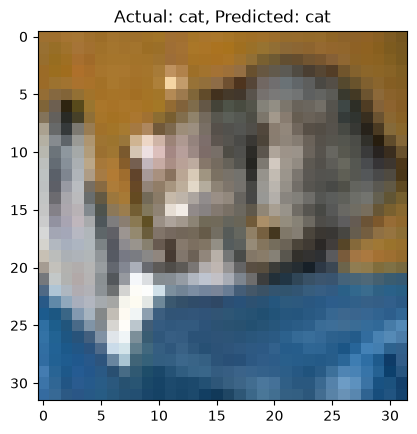

In [50]:
image = images[0].cpu()  # Move the image back to CPU for visualization

image = image / 2 + 0.5

image = image.permute(1, 2, 0)

plt.imshow(image)
plt.title(f"Actual: {test_dataset.classes[labels[0].item()]}, Predicted: {test_dataset.classes[predicted[0].item()]}")
plt.show()

<div style="border-left: 4px solid #059669; background: #ecfdf5; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Saving the learned model</strong><br><code>state_dict()</code> stores the learned parameters. To load them later, create the same <code>CNN</code> architecture first, load the state dictionary, move the model to the selected device, and call <code>eval()</code>.</div>

In [52]:
torch.save(
    model.state_dict(),
    "cnn_cifar10.pth"
)

In [53]:
model = CNN()

model.load_state_dict(
    torch.load(
        "cnn_cifar10.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)